In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import binom

### Case #1: $X$ is a discrete random variable and $Y = g(X)$ is a discrete function of $X$.

- Suppose $X$ is a binomial random variable with parameters $n$ and $p$, i.e., $X \sim Bin(n, p)$. The pmf of $X$ can be computed as follows:

$$ P[X=k] = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, 2, \ldots, n $$

- Let $Y = g(X) = (X - M)^+$ which is defined as: 

$$ (X - M)^+ = \begin{cases} 
      X - M & \text{if } X > M \\
      0 & \text{otherwise} 
   \end{cases} $$

- The pmf of $Y$ can be computed as follows:
$$P[Y=0] = P[X \leq M] = \sum_{k=0}^{M} P[X=k]$$
$$P[Y=y] = P[X = y + M] = P[X = k], \quad y = 1, 2, \ldots, n - M$$

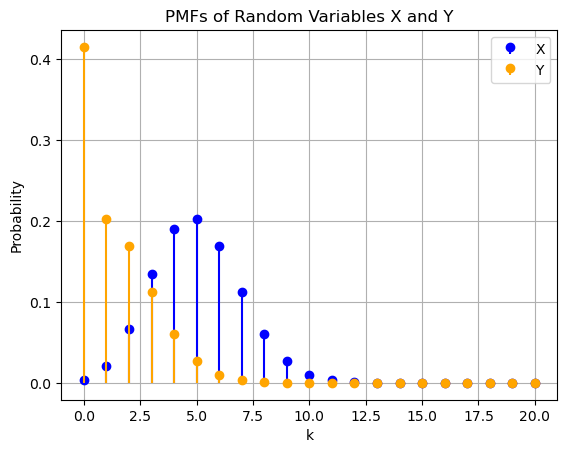

In [10]:
# Plot the PMFs of the two random variables on the same graph. X in Blue and Y in Orange
N = 20
p = 0.25
M = 4

K_range = np.arange(0, N+1)
pmf_X = np.array([binom.pmf(k, N, p) for k in K_range])

pmf_Y = np.zeros_like(pmf_X)
pmf_Y[0] = np.sum(pmf_X[:M+1])
pmf_Y[1:N-M+1] = pmf_X[M+1:]

plt.stem(K_range, pmf_X, linefmt='b-', markerfmt='bo', basefmt=' ')
plt.stem(K_range, pmf_Y, linefmt='orange', markerfmt='o', basefmt=' ')
plt.title('PMFs of Random Variables X and Y')
plt.xlabel('k')
plt.ylabel('Probability')
plt.legend(['X', 'Y'])
plt.grid(True)
plt.show()

### Case 3: $X$ is a continuous random variable and $Y = aX + b$ is a linear function.

- The PDF of $Y$ can be computed as follows: (Derivation to be done! Start with CDF and differentiate to get PDF)

$$f_Y(y) = \frac{1}{|a|} f_X\left(\frac{y - b}{a}\right)$$


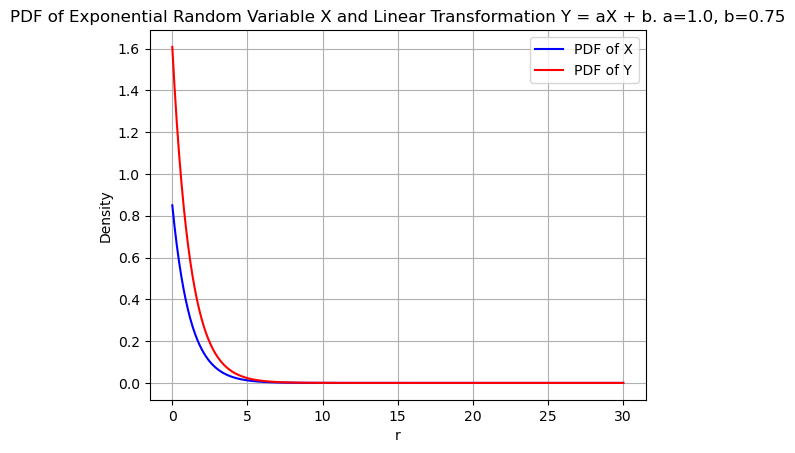

In [17]:
RANGE = 30
LAMBDA = 0.85
a = 1.0   # a has to be positive for the transformation to be valid
b = 0.75

r = np.linspace(0, RANGE, 1000)

# Define X as an exponential random variable with rate parameter lambda
pdf_X = LAMBDA * np.exp(-LAMBDA * r)

# Define Y = aX + b, where X is an exponential random variable
pdf_Y = (1/np.abs(a)) * LAMBDA * np.exp(-LAMBDA * (r - b) / a)

# Plot the PDF of X and Y on the same graph. X in Blue and Y in Red
plt.plot(r, pdf_X, color='b', label='PDF of X')
plt.plot(r, pdf_Y, color='r', label='PDF of Y')
plt.xlabel('r')
plt.ylabel('Density')
plt.title(f'PDF of Exponential Random Variable X and Linear Transformation Y = aX + b. a={a}, b={b}')
plt.legend()
plt.grid(True)
plt.show()